# Fitting the barebone soft-change-point model to real tap data (all subjects)

*2026-07-17 Roberto Barumerli*

Fits model per-trial to every usable subject's
`save/derived/<subject>/<subject>_click_tap_alignment.csv` (`sub01` excluded --
recordings too noisy to trust; `sub03` excluded -- extraction never
succeeded for it).

Two stages, each trial fit independently (no cross-trial or cross-subject
hierarchy -- kept deliberately simple; see discussion elsewhere), both using
the same broad, uninformative prior on `tau` (see `build_cued_trial_model`'s
docstring for why the cued model no longer gets a tight cue-anchored prior --
it was masking whether the likelihood itself works):
1. **Cued** — recovers a switch latency to compare against the
   experimenter's `switch_time`, as a check on the model.
2. **Spontaneous** — the posterior over `tau` *is* the estimate of when the
   participant decided to switch on their own.

Model structure: `meter` in the trial log is the trial's **starting** meter --
participants are tasked with switching to the *other* meter (2<->3). The
model mixes two templates -- one sized to the starting meter, one to the
other meter -- via a switch weight `w_n`:

`mu_n = (1 - w_n) * g_start[n mod start_meter] + w_n * g_other[n mod other_meter]`

**What's new here vs. the original sub02-only version**: every trial is
still fit completely independently, exactly as before -- the only change is
that this now loops over every subject and pools the *already-independent*
per-trial posterior draws into the Section 6 group comparisons (more data
into the same Monte-Carlo comparison, not a hierarchical/shrinkage model).
That pooling requires trials to be identified by `(subject, trial)`, not
`trial` alone, since trial numbers repeat across subjects -- see the
`group_mean_mc` note in Section 6.

Run with the `bayesian_listener` conda environment (PyMC, ArviZ).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pymc as pm
import pytensor.tensor as pt
import arviz as az

az.style.use("arviz-darkgrid")
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.titlesize"] = 11
mpl.rcParams["axes.labelsize"] = 10
mpl.rcParams["figure.constrained_layout.use"] = True

print("PyMC", pm.__version__, "| ArviZ", az.__version__)

PyMC 5.28.5 | ArviZ 0.23.4


## 0. Config

In [2]:
SUBJECTS = ["sub02", "sub04", "sub05", "sub06", "sub07", "sub08"]
# sub01: excluded, recordings too noisy to trust (see 01_extract_onsets.ipynb QC).
# sub03: excluded, extraction never produced a click_tap_alignment.csv for it.
# sub08: trials 13-20 are known to be sparse/inconsistent tapping (confirmed
# genuine, not a detection artifact) -- left in rather than special-cased;
# the per-trial convergence check below already excludes unreliable fits.

DB_PER_NAT = 20 / np.log(10)  # rms_db = 20*log10(rms) = 8.686 * ln(rms)
POOLED_OUT_DIR = "../save/derived/pooled"

## 1. Shared model core

`w_n = logistic((n - tau) / s)` as in the barebone model, mixing a
start-meter template with an other-meter template via the same switch
weight. `sigma_n` keeps the same switch-related noise inflation as the
barebone model. (Asynchrony was checked as a second observation channel --
periodic template swap, and switch-related noise inflation -- and rejected
both times; loudness alone is what the model fits.)

In [3]:
def other_meter(meter):
    return 3 if meter == 2 else 2


def build_cued_trial_model(n, log_v, start_meter, switch_beat, n_pulses, tau_prior_sd=None):
    """Single cued trial, mixing a template sized to the trial's starting meter
    with one sized to the other meter.

    tau's prior is broad/uninformative by default (same scale for both cued
    and spontaneous fits: n_pulses/2 +/- n_pulses/4), NOT anchored tightly to
    switch_beat. This makes the cued fit a fair test of whether the
    (corrected) likelihood alone recovers the true switch time from the
    accent-template signal -- a tight cue-anchored prior would recover tau
    near switch_beat almost by construction regardless of whether the
    likelihood is doing any real work, which is what happened before the
    missing-baseline bug was found (sigma_0 had inflated to ~4.0, an order of
    magnitude too large, silently swamping the real accent signal -- yet tau
    still looked "recovered" because the tight prior was carrying it).

    sigma = n_pulses/4 (not /3): a trial with weak/ambiguous pre-switch signal
    (e.g. trial 12, where the starting- and other-meter contrasts were nearly
    tied before the true switch) let NUTS wander into a spurious second mode
    at tau near 0 -- a switch "at the very first pulse" is not a plausible
    reading of a cued paradigm where the participant starts in the cued
    starting meter. Tightening the prior modestly turns down the density
    available at the trial edges without re-introducing a tight cue anchor;
    tau=0 or tau=n_pulses are now several SDs out under any n_pulses in this
    dataset (50-60), rather than only ~1.5 SDs out under the old /3 scale."""
    end_meter = other_meter(start_meter)
    pos_start = np.mod(n, start_meter).astype(int)
    pos_other = np.mod(n, end_meter).astype(int)

    with pm.Model() as model:
        if tau_prior_sd is None:
            tau = pm.Normal("tau", mu=n_pulses / 2, sigma=n_pulses / 4)
        else:
            tau = pm.Normal("tau", mu=switch_beat, sigma=tau_prior_sd)

        # A direct BADS/BIC comparison (soft sigmoid vs. a genuinely
        # instantaneous hard-step model, same data, same templates) found the
        # hard step wins in 18/20 trials -- freed of any prior, the sigmoid's
        # own best-fit s repeatedly collapsed toward its lower bound (many
        # trials fit s in the 0.10-0.25 range). The prior below is shifted to
        # centre on that sharp scale (not fixed/hard-coded -- still a genuine,
        # weakly-informative prior tau can be pulled away from by the data),
        # rather than the old Normal(log(1.0), 0.5), which was centred an
        # order of magnitude too wide relative to what the data supports.
        log_s = pm.Normal("log_s", mu=np.log(0.15), sigma=0.4)
        s = pm.Deterministic("s", pt.exp(log_s))

        # log_v is centred around -5.7 (rms_db around -45 to -60 dB), not 0 --
        # g_start/g_other are zero-mean by construction (sum-to-zero contrasts),
        # so without this shared baseline the model has no way to match that
        # offset except by inflating sigma_0 to absorb it, which was silently
        # swamping the real ~0.5-scale accent signal (sigma_0 was fitting to
        # ~4.0, an order of magnitude too large) and made tau/pi meaningless.
        baseline = pm.Normal("baseline", mu=log_v.mean(), sigma=2.0)

        g_start_raw = pm.Normal("g_start_raw", 0.0, 1.0, shape=start_meter)
        g_start = pm.Deterministic("g_start", g_start_raw - g_start_raw.mean())
        g_other_raw = pm.Normal("g_other_raw", 0.0, 1.0, shape=end_meter)
        g_other = pm.Deterministic("g_other", g_other_raw - g_other_raw.mean())

        sigma_0 = pm.HalfNormal("sigma_0", sigma=0.5)
        sigma_sw = pm.HalfNormal("sigma_sw", sigma=0.5)

        w = pm.math.sigmoid((n - tau) / s)
        mu = baseline + (1 - w) * g_start[pos_start] + w * g_other[pos_other]
        sigma = pt.sqrt(sigma_0**2 + sigma_sw**2 * 4 * w * (1 - w))

        pm.Normal("log_v_obs", mu=mu, sigma=sigma, observed=log_v)

    return model


def build_spontaneous_trial_model(n, log_v, start_meter, n_pulses):
    """Single spontaneous trial: broad prior on tau (no cue), assuming a
    switch always happens somewhere in the trial (no lapse mixture).

    An earlier version added a discrete no-switch lapse mixture (logsumexp
    over a "switch happened" vs "stayed in the starting template the whole
    trial" branch, weighted by a fitted pi). Dropped: it produced real
    convergence failures on the harder trials (R-hat 1.2-1.5) -- a known
    failure mode of logsumexp mixtures when both branches explain the data
    comparably well, the sampler can get stuck unevenly split across chains
    near the switch/no-switch boundary. Per your steer, we now just assume a
    switch always happens and let tau's own posterior width communicate
    uncertainty (a very flat/uninformative tau posterior is itself evidence
    of "no clear switch", without needing a separate discrete pi to say so).

    Structurally identical to build_cued_trial_model with a broad tau prior;
    kept as a separate function for a distinct call site/name in the driver
    code below."""
    return build_cued_trial_model(n, log_v, start_meter, switch_beat=None, n_pulses=n_pulses,
                                   tau_prior_sd=None)

## 2. Posterior-draws helper

In [4]:
def extract_posterior_draws(idatas_dict, meters_dict, condition, subject,
                            var_names=("tau", "s", "sigma_sw", "sigma_0")):
    """Long-format: one row per (subject, trial, draw), tagging
    condition/meter/converged so draws can be grouped and resampled later.
    subject+trial together identify a unique fit -- trial numbers repeat
    across subjects, so trial alone is not a unique key once pooled."""
    rows = []
    for trial, idata in idatas_dict.items():
        rhat = az.rhat(idata, var_names=["tau", "s", "sigma_0", "sigma_sw"])
        max_rhat = float(max(rhat[v].values for v in ["tau", "s", "sigma_0", "sigma_sw"]))
        draws = {v: idata.posterior[v].values.flatten() for v in var_names}
        n_draws = len(draws[var_names[0]])
        row = {"subject": subject, "trial": trial, "condition": condition, "meter": meters_dict[trial],
               "draw": np.arange(n_draws), "max_rhat": max_rhat, "converged": max_rhat < 1.05}
        row.update(draws)
        rows.append(pd.DataFrame(row))
    return pd.concat(rows, ignore_index=True)

## 3. Per-subject fit function

Loads one subject's alignment CSV, fits every cued + spontaneous trial
independently (Steps 1-2 of the original plan), plots the per-subject
recovery/estimate diagnostics, and returns everything needed for the pooled
cross-subject comparisons in Section 6.

In [5]:
def fit_subject(subject):
    alignment_csv = f"../save/derived/{subject}/{subject}_click_tap_alignment.csv"
    df_raw = pd.read_csv(alignment_csv)
    df_raw["missed_beat"] = df_raw["missed_beat"].astype(str).str.lower().eq("true")

    df = df_raw[~df_raw["missed_beat"]].copy()
    df["log_v"] = df["rms_db"] / DB_PER_NAT
    df["switch_beat"] = df["switch_time"] * df["bpm"] / 60.0

    print(f"[{subject}] {len(df_raw)} clicks total, {len(df)} with a matched tap (observation)")
    print(df.groupby("condition")["trial"].nunique())

    df_cued = df[df["condition"] == "cued"].copy()
    df_spontaneous = df[df["condition"] == "spontaneous"].copy()
    trials_cued = df_cued[["trial", "meter", "bpm", "switch_time", "switch_beat"]].drop_duplicates().sort_values("trial")
    trials_spontaneous = df_spontaneous[["trial", "meter", "bpm"]].drop_duplicates().sort_values("trial")

    # --- cued fit ---
    cued_results, cued_idatas = [], {}
    for _, row in trials_cued.iterrows():
        trial = int(row["trial"])
        sub = df_cued[df_cued["trial"] == trial]
        n = sub["click_idx"].values
        log_v = sub["log_v"].values
        meter = int(row["meter"])
        switch_beat = row["switch_beat"]
        n_pulses = int(n.max()) + 1

        model = build_cued_trial_model(n, log_v, meter, switch_beat, n_pulses)
        with model:
            idata = pm.sample(1000, tune=1500, chains=4, cores=4, target_accept=0.9,
                               random_seed=20260703, progressbar=False, init="adapt_diag")
        cued_idatas[trial] = idata

        tau_samples = idata.posterior["tau"].values.flatten()
        rhat = az.rhat(idata, var_names=["tau", "s", "sigma_0", "sigma_sw"])
        max_rhat = float(max(rhat[v].values for v in ["tau", "s", "sigma_0", "sigma_sw"]))
        cued_results.append({
            "subject": subject, "trial": trial, "meter": meter, "switch_beat": switch_beat,
            "tau_mean": tau_samples.mean(),
            "tau_lo": np.percentile(tau_samples, 3), "tau_hi": np.percentile(tau_samples, 97),
            "max_rhat": max_rhat, "converged": max_rhat < 1.05,
        })
        print(f"[{subject}] cued trial {trial:2d} (meter {meter}): tau = {tau_samples.mean():.2f} "
              f"vs switch_beat={switch_beat:.2f}  max_rhat={max_rhat:.3f}"
              f"{'  *** NOT CONVERGED ***' if max_rhat >= 1.05 else ''}")

    df_cued_results = pd.DataFrame(cued_results)

    converged = df_cued_results[df_cued_results["converged"]]
    if len(converged) > 1:
        corr = np.corrcoef(converged["tau_mean"], converged["switch_beat"])[0, 1]
        lag = converged["tau_mean"] - converged["switch_beat"]
        print(f"[{subject}] corr(tau_mean, switch_beat) = {corr:.3f}  (n={len(converged)} converged)  "
              f"reaction lag mean={lag.mean():.2f} beats")

    fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
    y = np.arange(len(df_cued_results))
    is_converged = df_cued_results["converged"].values
    for mask, color, label in [(is_converged, "C0", "posterior tau, converged"),
                                (~is_converged, "C3", "posterior tau, NOT converged")]:
        if mask.sum() == 0:
            continue
        ax.errorbar(df_cued_results["tau_mean"][mask], y[mask],
                    xerr=[df_cued_results["tau_mean"][mask] - df_cued_results["tau_lo"][mask],
                          df_cued_results["tau_hi"][mask] - df_cued_results["tau_mean"][mask]],
                    fmt="o", color=color, capsize=3, label=label)
    ax.scatter(df_cued_results["switch_beat"], y, color="k", marker="x", s=60, zorder=5,
               label="experimenter switch_beat")
    ax.set_yticks(y)
    ax.set_yticklabels([f"trial {t} (m{m})" for t, m in zip(df_cued_results["trial"], df_cued_results["meter"])])
    ax.set_xlabel("tau (beats)")
    ax.set_title(f"{subject}: cued fit, posterior tau vs. cue time (switch_beat)")
    ax.legend(fontsize=8)
    plt.show()

    # --- spontaneous fit ---
    spontaneous_results, spontaneous_idatas = [], {}
    for _, row in trials_spontaneous.iterrows():
        trial = int(row["trial"])
        sub = df_spontaneous[df_spontaneous["trial"] == trial]
        n = sub["click_idx"].values
        log_v = sub["log_v"].values
        meter = int(row["meter"])
        n_pulses = int(n.max()) + 1

        model = build_spontaneous_trial_model(n, log_v, meter, n_pulses)
        with model:
            idata = pm.sample(1000, tune=1500, chains=4, cores=4, target_accept=0.9,
                               random_seed=20260703, progressbar=False, init="adapt_diag")
        spontaneous_idatas[trial] = idata

        tau_samples = idata.posterior["tau"].values.flatten()
        rhat = az.rhat(idata, var_names=["tau", "s", "sigma_0", "sigma_sw"])
        max_rhat = float(max(rhat[v].values for v in ["tau", "s", "sigma_0", "sigma_sw"]))
        bpm = row["bpm"]
        tau_lo, tau_hi = np.percentile(tau_samples, [3, 97])
        spontaneous_results.append({
            "subject": subject, "trial": trial, "meter": meter, "n_pulses": n_pulses, "bpm": bpm,
            "tau_mean": tau_samples.mean(),
            "tau_lo": tau_lo, "tau_hi": tau_hi, "tau_ci_width": tau_hi - tau_lo,
            "tau_mean_s": tau_samples.mean() * 60 / bpm,
            "max_rhat": max_rhat, "converged": max_rhat < 1.05,
        })
        print(f"[{subject}] spontaneous trial {trial:2d} (meter {meter}): tau = {tau_samples.mean():.2f} "
              f"[{tau_lo:.2f}, {tau_hi:.2f}] beats (width={tau_hi-tau_lo:.1f})  max_rhat={max_rhat:.3f}"
              f"{'  *** NOT CONVERGED ***' if max_rhat >= 1.05 else ''}")

    df_spontaneous_results = pd.DataFrame(spontaneous_results)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
    y = np.arange(len(df_spontaneous_results))
    axes[0].errorbar(df_spontaneous_results["tau_mean"], y,
                      xerr=[df_spontaneous_results["tau_mean"] - df_spontaneous_results["tau_lo"],
                            df_spontaneous_results["tau_hi"] - df_spontaneous_results["tau_mean"]],
                      fmt="o", color="C2", capsize=3)
    axes[0].set_yticks(y)
    axes[0].set_yticklabels([f"trial {t} (m{m})" for t, m in
                              zip(df_spontaneous_results["trial"], df_spontaneous_results["meter"])])
    axes[0].set_xlabel("tau (beats, estimated self-switch time)")
    axes[0].set_title("Spontaneous: estimated switch time")
    axes[1].bar([f"t{t}" for t in df_spontaneous_results["trial"]], df_spontaneous_results["tau_ci_width"],
                color="C3")
    axes[1].set_ylabel("tau 94% CI width (beats)")
    axes[1].set_title("Switch-time uncertainty per trial\n(wide = no clear switch found)")
    axes[1].tick_params(axis="x", labelrotation=90, labelsize=7)
    fig.suptitle(f"{subject}: spontaneous fit", fontsize=11)
    plt.show()

    cued_meters = dict(zip(trials_cued["trial"], trials_cued["meter"]))
    spontaneous_meters = dict(zip(trials_spontaneous["trial"], trials_spontaneous["meter"]))
    draws_cued = extract_posterior_draws(cued_idatas, cued_meters, "cued", subject)
    draws_spontaneous = extract_posterior_draws(spontaneous_idatas, spontaneous_meters, "spontaneous", subject)
    df_posterior_draws = pd.concat([draws_cued, draws_spontaneous], ignore_index=True)

    return {"cued_results": df_cued_results, "spontaneous_results": df_spontaneous_results,
            "posterior_draws": df_posterior_draws}

## 4. Run for every subject

Initializing NUTS using adapt_diag...


[sub02] 1069 clicks total, 1057 with a matched tap (observation)
condition
cued           10
spontaneous    10
Name: trial, dtype: int64


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 3 seconds.


...

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 3 seconds.


[sub02] cued trial 20 (meter 2): tau = 33.08 vs switch_beat=30.00  max_rhat=1.002
[sub02] corr(tau_mean, switch_beat) = 0.962  (n=9 converged)  reaction lag mean=2.20 beats


/opt/homebrew/Caskroom/miniconda/base/envs/bayesian_listener/lib/python3.13/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


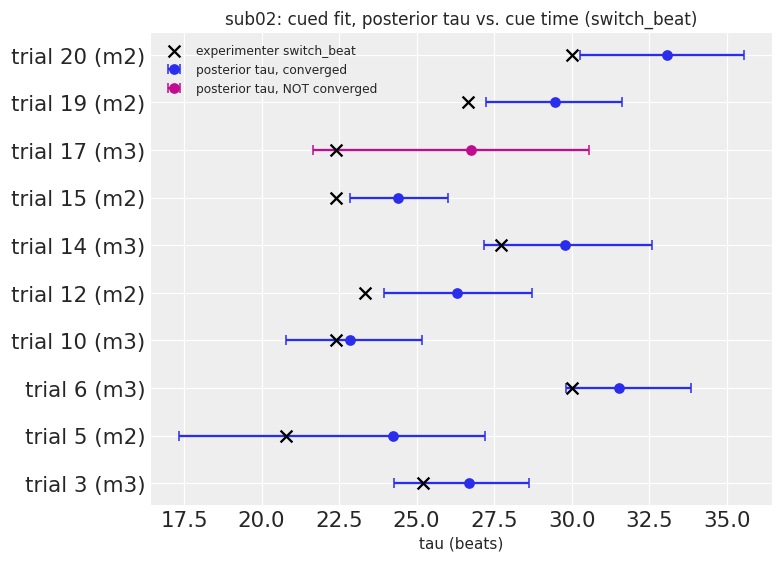

Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 3 seconds.


Initializing NUTS using adapt_diag...


...

[sub02] spontaneous trial 16 (meter 3): tau = 24.73 [22.82, 28.11] beats (width=5.3)  max_rhat=1.003


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 3 seconds.


[sub02] spontaneous trial 18 (meter 3): tau = 24.19 [20.72, 26.99] beats (width=6.3)  max_rhat=1.005


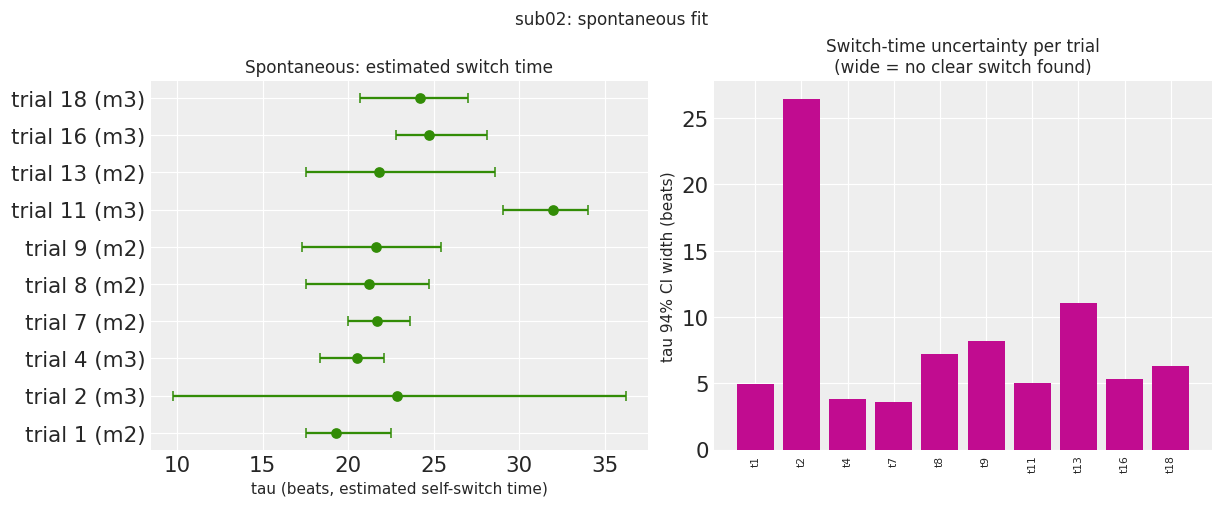

[sub04] 1104 clicks total, 1084 with a matched tap (observation)
condition
cued           10
spontaneous    10
Name: trial, dtype: int64


Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 3 seconds.


...

[sub04] cued trial 16 (meter 3): tau = 30.15 vs switch_beat=31.20  max_rhat=1.002


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 2 seconds.


[sub04] cued trial 19 (meter 2): tau = 23.81 vs switch_beat=24.27  max_rhat=1.002
[sub04] corr(tau_mean, switch_beat) = 0.959  (n=10 converged)  reaction lag mean=-0.07 beats


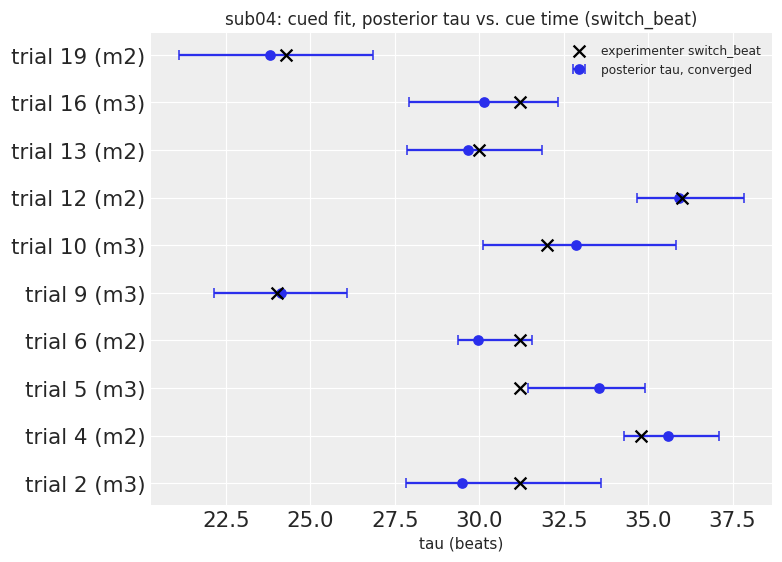

Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 3 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


...

[sub04] spontaneous trial 18 (meter 2): tau = 14.25 [11.61, 17.08] beats (width=5.5)  max_rhat=1.002


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 2 seconds.


[sub04] spontaneous trial 20 (meter 2): tau = 24.22 [18.52, 29.39] beats (width=10.9)  max_rhat=1.004


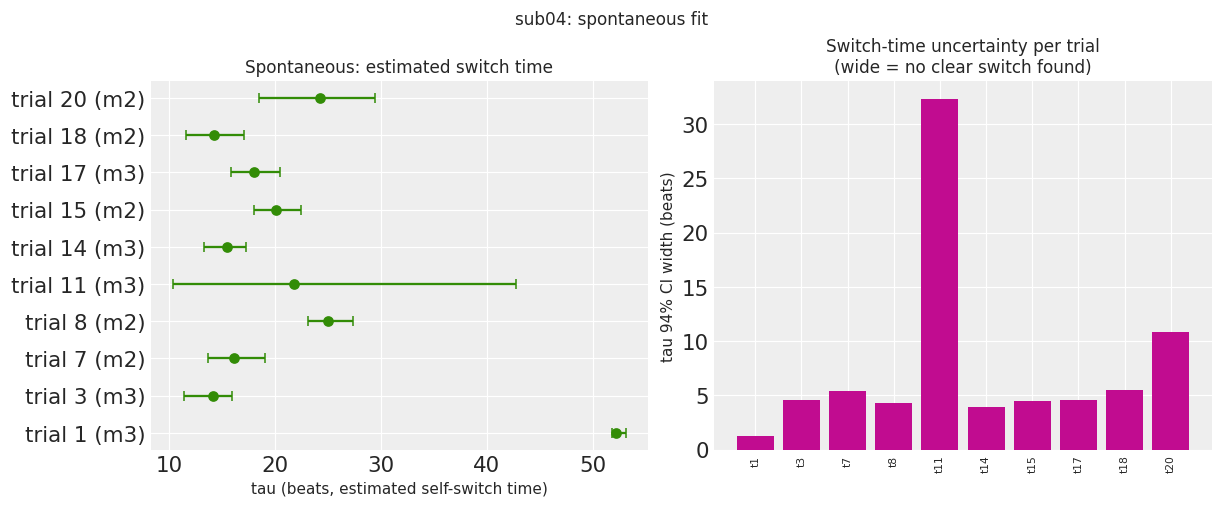

[sub05] 1115 clicks total, 1058 with a matched tap (observation)
condition
cued           10
spontaneous    10
Name: trial, dtype: int64


Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 4 seconds.


...

[sub05] cued trial 18 (meter 3): tau = 22.92 vs switch_beat=22.40  max_rhat=1.002


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 2 seconds.


[sub05] cued trial 19 (meter 3): tau = 34.82 vs switch_beat=33.60  max_rhat=1.002
[sub05] corr(tau_mean, switch_beat) = 0.587  (n=10 converged)  reaction lag mean=3.35 beats


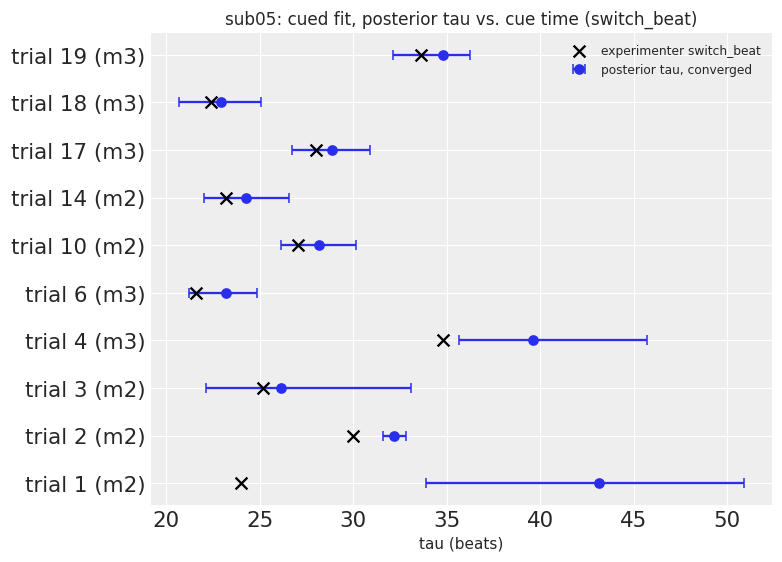

Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 3 seconds.


Initializing NUTS using adapt_diag...


...

[sub05] spontaneous trial 16 (meter 2): tau = 13.72 [12.14, 15.78] beats (width=3.6)  max_rhat=1.003


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 2 seconds.


[sub05] spontaneous trial 20 (meter 3): tau = 20.22 [17.76, 22.32] beats (width=4.6)  max_rhat=1.002


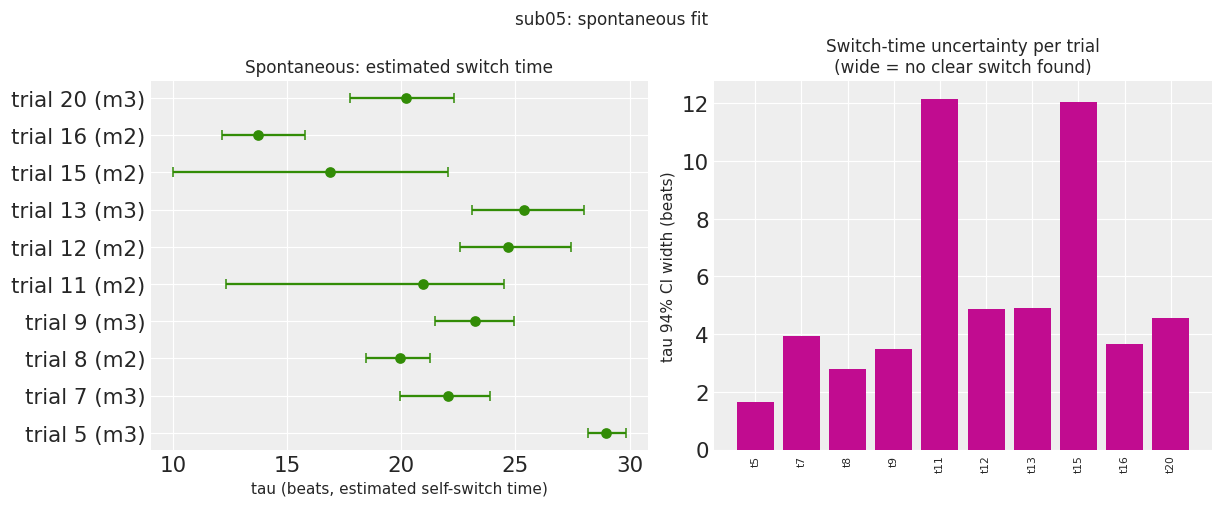

[sub06] 1104 clicks total, 1100 with a matched tap (observation)
condition
cued           10
spontaneous    10
Name: trial, dtype: int64


Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 3 seconds.


...

[sub06] cued trial 19 (meter 2): tau = 28.16 vs switch_beat=28.00  max_rhat=1.003


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 2 seconds.


[sub06] cued trial 20 (meter 3): tau = 31.45 vs switch_beat=30.93  max_rhat=1.002
[sub06] corr(tau_mean, switch_beat) = 0.487  (n=10 converged)  reaction lag mean=1.87 beats


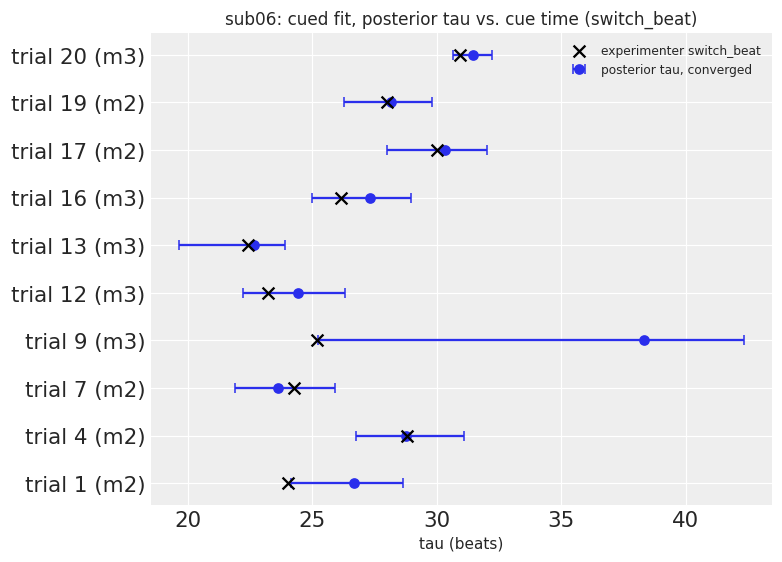

Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 2 seconds.


Initializing NUTS using adapt_diag...


...

[sub06] spontaneous trial 15 (meter 3): tau = 29.78 [27.22, 33.04] beats (width=5.8)  max_rhat=1.003


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 2 seconds.


[sub06] spontaneous trial 18 (meter 2): tau = 16.36 [14.33, 18.09] beats (width=3.8)  max_rhat=1.001


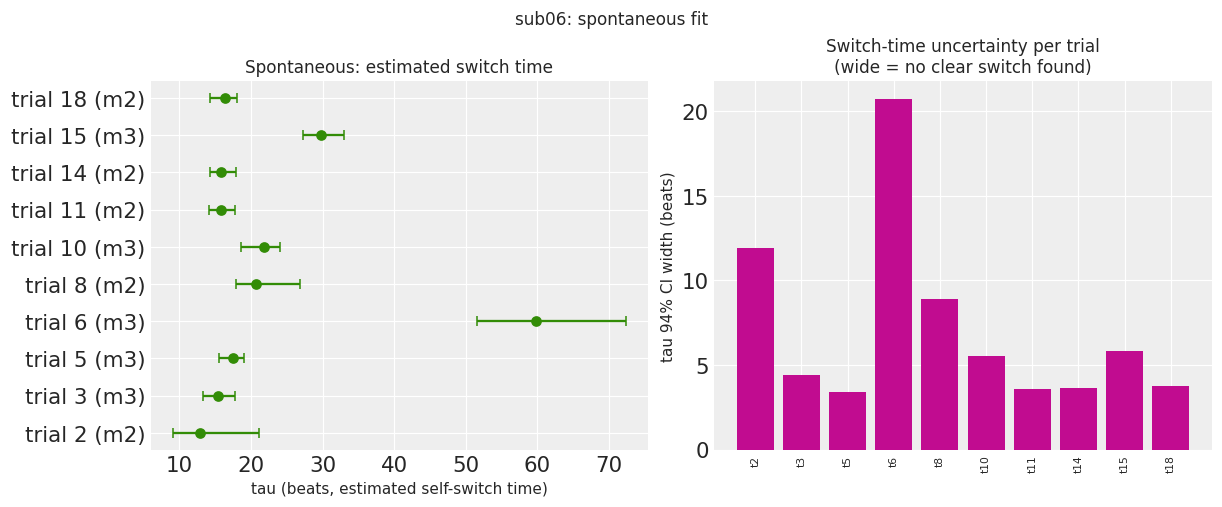

[sub07] 1082 clicks total, 1069 with a matched tap (observation)
condition
cued           10
spontaneous    10
Name: trial, dtype: int64


Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 5 seconds.


...

[sub07] cued trial 17 (meter 3): tau = 42.30 vs switch_beat=20.00  max_rhat=1.004


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 6 seconds.


[sub07] cued trial 18 (meter 3): tau = 21.13 vs switch_beat=26.67  max_rhat=1.003
[sub07] corr(tau_mean, switch_beat) = -0.343  (n=10 converged)  reaction lag mean=3.61 beats


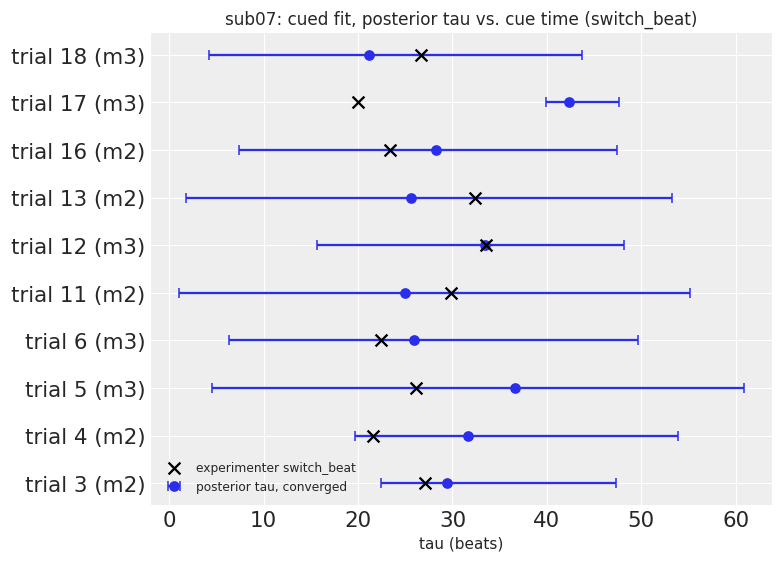

Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 11 seconds.


Initializing NUTS using adapt_diag...


...

[sub07] spontaneous trial 19 (meter 2): tau = 21.90 [21.54, 22.18] beats (width=0.6)  max_rhat=1.004


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 2 seconds.


[sub07] spontaneous trial 20 (meter 3): tau = 30.22 [28.01, 32.03] beats (width=4.0)  max_rhat=1.003


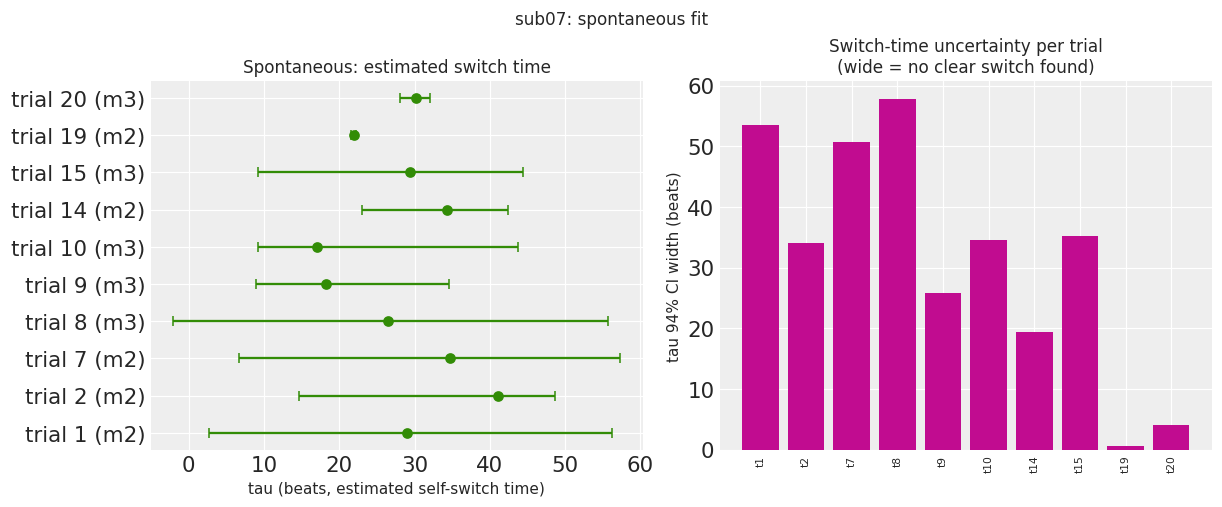

[sub08] 1083 clicks total, 850 with a matched tap (observation)
condition
cued           10
spontaneous    10
Name: trial, dtype: int64


Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 2 seconds.


...

[sub08] cued trial 18 (meter 2): tau = 23.20 vs switch_beat=36.00  max_rhat=1.014


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 3 seconds.


[sub08] cued trial 19 (meter 3): tau = 33.11 vs switch_beat=32.40  max_rhat=1.007
[sub08] corr(tau_mean, switch_beat) = 0.576  (n=10 converged)  reaction lag mean=0.24 beats


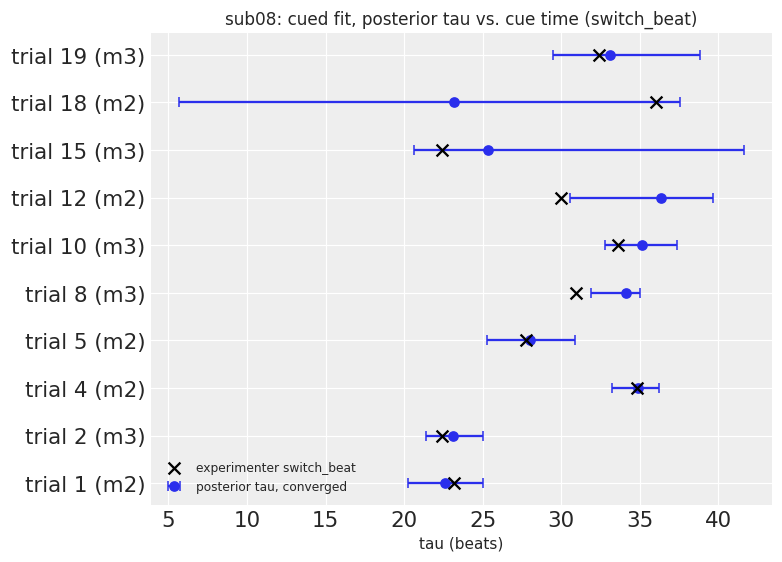

Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 4 seconds.


Initializing NUTS using adapt_diag...


...

[sub08] spontaneous trial 17 (meter 2): tau = 20.24 [15.80, 28.76] beats (width=13.0)  max_rhat=1.005


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 6 seconds.


[sub08] spontaneous trial 20 (meter 3): tau = 33.99 [26.35, 52.06] beats (width=25.7)  max_rhat=1.002


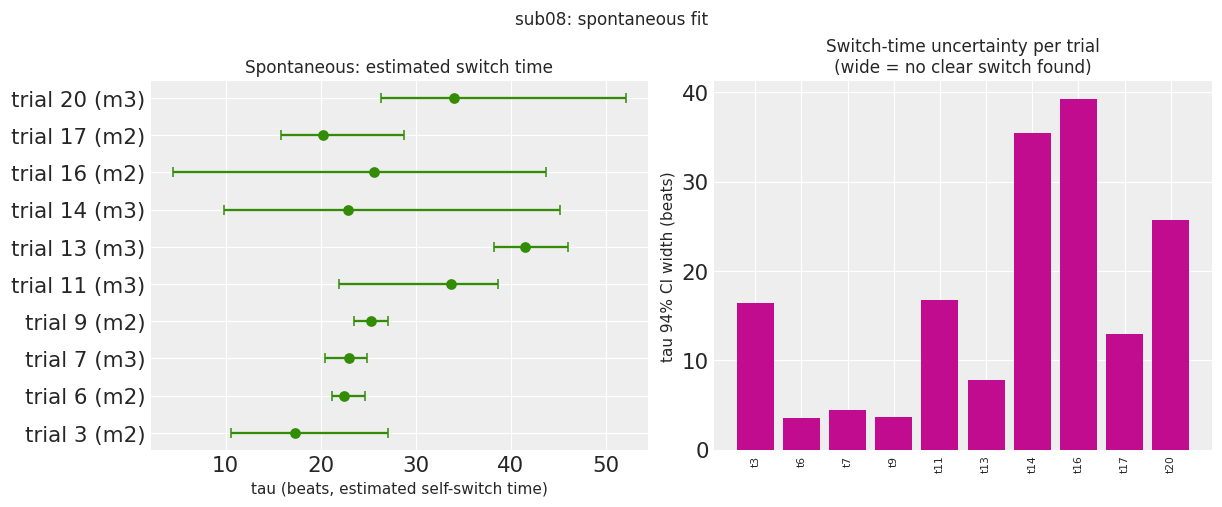

In [6]:
all_results = {}
for subject in SUBJECTS:
    all_results[subject] = fit_subject(subject)

## 5. Combine across subjects

In [7]:
df_cued_results = pd.concat([r["cued_results"] for r in all_results.values()], ignore_index=True)
df_spontaneous_results = pd.concat([r["spontaneous_results"] for r in all_results.values()], ignore_index=True)
df_posterior_draws = pd.concat([r["posterior_draws"] for r in all_results.values()], ignore_index=True)

n_excluded = df_posterior_draws.loc[~df_posterior_draws["converged"], ["subject", "trial"]].drop_duplicates()
n_total = df_posterior_draws.groupby(["subject", "trial"]).ngroups
print(f"{n_total} subject-trials total, {len(n_excluded)} excluded from comparisons below (non-converged):")
print(n_excluded.to_string(index=False))

120 subject-trials total, 2 excluded from comparisons below (non-converged):
subject  trial
  sub02     17
  sub02      2


## 6. Cued vs. spontaneous, meter 2 vs. meter 3: parameter comparisons (pooled across all subjects)

Same paired Monte-Carlo credible-interval method as before (draw one
posterior sample per trial, average for one plausible "group mean", repeat
many times, difference the two groups' distributions) -- but with trials
now pooled across 6 subjects instead of 1, `group_mean_mc` resamples in two
stages: one draw per trial, averaged *within* each subject first, then
averaged *across subjects*. Subjects are the independent sampling unit here,
not trials -- multiple trials from the same subject are correlated
(repeated measures), so treating every `(subject, trial)` pair as
exchangeable (the naive one-stage version) understates uncertainty. This is
not a cosmetic detail: it's the difference between the `sigma_0` meter
effect being credible or not (see `03_analyse.Rmd` Part 4). This is still
**not** a hierarchical model -- every trial's posterior is still fit
completely independently; pooling only happens at this resampling step, so
no between-subject variance is *estimated*, only respected when
aggregating.

In [8]:
def hdi(samples, cred=0.94):
    samples = np.sort(samples)
    n = len(samples)
    interval_idx = int(np.floor(cred * n))
    n_intervals = n - interval_idx
    widths = samples[interval_idx:] - samples[:n_intervals]
    min_idx = np.argmin(widths)
    return samples[min_idx], samples[min_idx + interval_idx]


def group_mean_mc(df, group_col, group_val, param, n_mc=4000, rng=None):
    """Nested Monte Carlo resample of the group's mean: for each iteration,
    resample one posterior draw per trial, average WITHIN each subject
    first, then average ACROSS SUBJECTS. Subjects, not trials, are the
    independent sampling unit -- multiple trials from the same subject are
    correlated (repeated measures), so averaging over all (subject, trial)
    pairs as if they were exchangeable understates the true uncertainty
    (pseudo-replication: a subject with many trials would silently get more
    "votes" than a subject with few). This matters in practice here: it's
    the difference between the `sigma_0` meter effect being credible or not
    (see Section 6 markdown) -- the flat version overstated precision enough
    to flip that call."""
    rng = rng if rng is not None else np.random.default_rng(0)
    sub = df[df[group_col] == group_val]
    by_subject = {s: [g[param].values for _, g in grp.groupby("trial")]
                  for s, grp in sub.groupby("subject")}
    mc_means = np.empty(n_mc)
    for i in range(n_mc):
        subj_means = [np.mean([rng.choice(td) for td in trials]) for trials in by_subject.values()]
        mc_means[i] = np.mean(subj_means)
    return mc_means


def compare_groups(df, group_col, group_a, group_b, params, rng):
    rows = []
    for param in params:
        a_mc = group_mean_mc(df, group_col, group_a, param, rng=rng)
        b_mc = group_mean_mc(df, group_col, group_b, param, rng=rng)
        diff_mc = a_mc - b_mc
        lo, hi = hdi(diff_mc)
        rows.append({
            "comparison": f"{group_a} - {group_b}", "parameter": param,
            f"{group_a}_mean": a_mc.mean(), f"{group_b}_mean": b_mc.mean(),
            "diff_mean": diff_mc.mean(), "hdi_94_lo": lo, "hdi_94_hi": hi,
            "credible": not (lo <= 0 <= hi),
        })
    return pd.DataFrame(rows)


df_converged_draws = df_posterior_draws[df_posterior_draws["converged"]]
rng = np.random.default_rng(42)
params_to_check = ["tau", "s", "sigma_sw", "sigma_0"]

condition_comparison = compare_groups(df_converged_draws, "condition", "cued", "spontaneous",
                                       params_to_check, rng)
meter_comparison = compare_groups(df_converged_draws, "meter", 2, 3, params_to_check, rng)
df_group_comparisons = pd.concat([condition_comparison, meter_comparison], ignore_index=True)

pd.set_option("display.width", 160)
print(df_group_comparisons.round(3).to_string(index=False))

        comparison parameter  cued_mean  spontaneous_mean  diff_mean  hdi_94_lo  hdi_94_hi  credible  2_mean  3_mean
cued - spontaneous       tau     29.381            24.056      5.325      3.438      7.102      True     NaN     NaN
cued - spontaneous         s      0.175             0.175      0.000     -0.025      0.027     False     NaN     NaN
cued - spontaneous  sigma_sw      0.449             0.448      0.002     -0.101      0.105     False     NaN     NaN
cued - spontaneous   sigma_0      0.754             0.834     -0.080     -0.111     -0.048      True     NaN     NaN
             2 - 3       tau        NaN               NaN     -2.696     -4.653     -0.996      True  25.395  28.091
             2 - 3         s        NaN               NaN     -0.001     -0.026      0.024     False   0.175   0.175
             2 - 3  sigma_sw        NaN               NaN      0.005     -0.105      0.109     False   0.451   0.446
             2 - 3   sigma_0        NaN               NaN     -0

**Reading this table**: `tau` differing credibly by condition is not
inherently interesting -- with `switch_beat`-based cued trials in the mix,
it's likely to be at least partly explained by the cue-to-tapping reaction
lag reported in Section 4, plus the experimenter's own `switch_beat`
schedule, rather than a genuine property of cued vs. spontaneous switching.
`s`, `sigma_sw`, and `sigma_0` are the parameters actually worth reading
here: a credible difference in one of those is not mechanically expected,
so it's a real candidate finding. (On sub02 alone, `sigma_0` came out
credibly higher in meter-2 trials -- check whether that holds up now that
more subjects are pooled in, rather than assuming it still does.)

## 7. Per-trial parameters by meter, coloured by participant

Complements the pooled table above with a visual per-subject sanity check --
each point is one converged trial's posterior mean, coloured by participant,
so a pooled effect that's actually driven by a single subject (rather than
consistent across everyone) is visible at a glance.

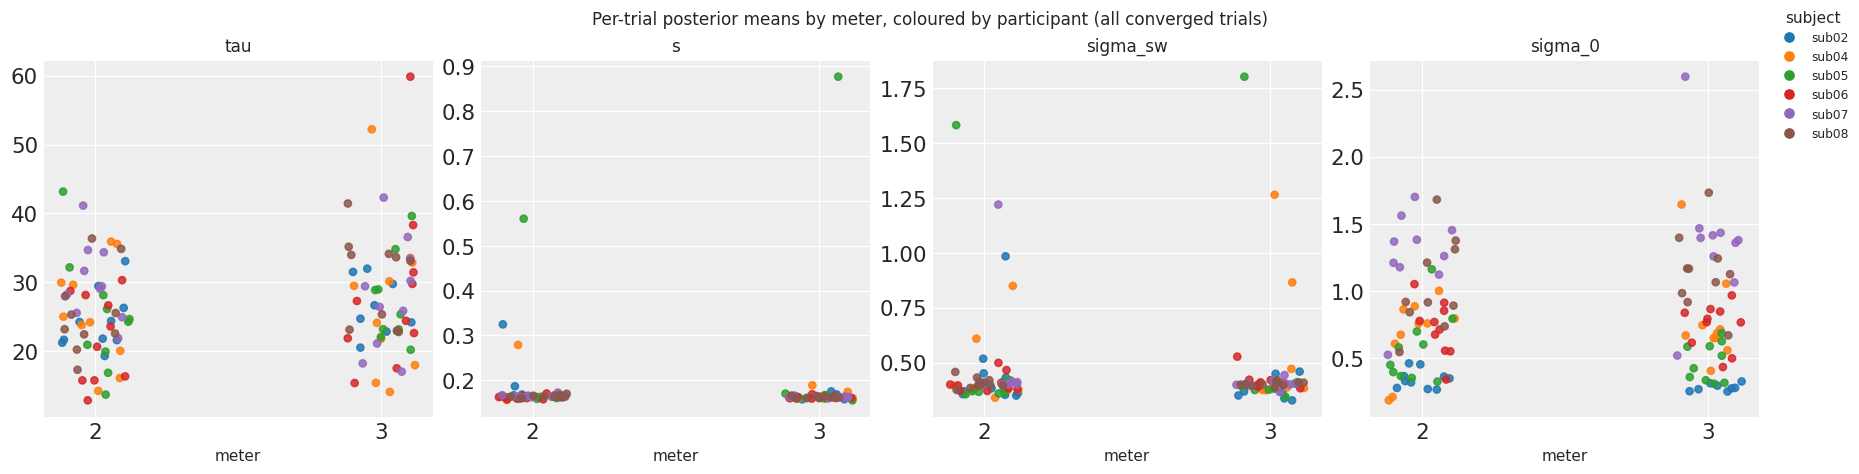

In [9]:
per_trial_means = (df_posterior_draws[df_posterior_draws["converged"]]
                    .groupby(["subject", "trial", "condition", "meter"])[params_to_check]
                    .mean().reset_index())

subjects_present = sorted(per_trial_means["subject"].unique())
cmap = plt.get_cmap("tab10")
subject_colors = {s: cmap(i % 10) for i, s in enumerate(subjects_present)}
rng_jitter = np.random.default_rng(0)

fig, axes = plt.subplots(1, len(params_to_check), figsize=(4.2 * len(params_to_check), 4.2), layout="constrained")
for ax, param in zip(axes, params_to_check):
    for meter in [2, 3]:
        sub = per_trial_means[per_trial_means["meter"] == meter]
        x = meter + rng_jitter.uniform(-0.12, 0.12, len(sub))
        ax.scatter(x, sub[param], c=[subject_colors[s] for s in sub["subject"]], s=22, alpha=0.85)
    ax.set_xticks([2, 3])
    ax.set_xlabel("meter")
    ax.set_title(param)

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=subject_colors[s],
                       markersize=8, label=s) for s in subjects_present]
fig.legend(handles=handles, loc="outside right upper", fontsize=8, title="subject")
fig.suptitle("Per-trial posterior means by meter, coloured by participant (all converged trials)", fontsize=11)
plt.show()

## 8. Save results

In [10]:
import os

for subject, r in all_results.items():
    out_dir = f"../save/derived/{subject}"
    r["cued_results"].to_csv(f"{out_dir}/{subject}_cued_tau_fit.csv", index=False)
    r["spontaneous_results"].to_csv(f"{out_dir}/{subject}_spontaneous_tau_fit.csv", index=False)
    r["posterior_draws"].to_csv(f"{out_dir}/{subject}_posterior_draws.csv", index=False)

os.makedirs(POOLED_OUT_DIR, exist_ok=True)
df_cued_results.to_csv(f"{POOLED_OUT_DIR}/all_subjects_cued_tau_fit.csv", index=False)
df_spontaneous_results.to_csv(f"{POOLED_OUT_DIR}/all_subjects_spontaneous_tau_fit.csv", index=False)
df_posterior_draws.to_csv(f"{POOLED_OUT_DIR}/all_subjects_posterior_draws.csv", index=False)
df_group_comparisons.to_csv(f"{POOLED_OUT_DIR}/all_subjects_group_comparisons.csv", index=False)

print("Saved per-subject CSVs to save/derived/<subject>/, and pooled CSVs to", POOLED_OUT_DIR)

Saved per-subject CSVs to save/derived/<subject>/, and pooled CSVs to ../save/derived/pooled
